In [7]:
import numpy as np
import cupy as cp
import spreadinterp
import libMobility as lm
from propagate_vslip import libmobility_electroosmotic_flow, plotter
import matplotlib.pyplot as plt

# Vslip is given in m/s with Vrms = 1V and Lambda = 1
# P. Garcia-Sanchez uses Vpp = 6V so Vrms = 6/sqrt(2) V
# They state that Lambda = 0.03 to mach the experimental data
# We will use the same values for our simulations

Lambda = 0.03
Vrms = (6 / np.sqrt(2))  # Vrms in Volts
um2m = 1e6  # Conversion factor from m/s to um/s
v_slip = cp.load('Vslip.npy')[1:-1,0]*um2m*Vrms**2*Lambda

Lx0 = 160  # um
Lz0 = 190  # um
hydrodynamicRadius = 1 # um This is the radius of the particles determines how many particles are in the simulation

# Kernel of interpolation can be changed, using the one that gives the best results
kernel = spreadinterp.create_kernel('gaussian', width=4*hydrodynamicRadius, cutoff=12*hydrodynamicRadius)
#kernel = spreadinterp.create_kernel('peskin3pt')

#Number of copies of the system in the x direction. [Number of electrodes = 4*n_repeats]
n_repeats = 20

Lx_min_trac = -Lx0
Lx_max_trac = Lx0
Nx_trac = 1000
Lz_min_trac = 0
Lz_max_trac = Lz0

In [ ]:
grid_pos, grid_vel = libmobility_electroosmotic_flow(
        v_slip=v_slip,
        hydrodynamicRadius=hydrodynamicRadius,
        n_repeats=n_repeats,
        Lx0=Lx0,
        Lz0=Lz0,
        kernel=kernel,
        Lx_min_trac=Lx_min_trac,
        Lx_max_trac=Lx_max_trac,
        Lz_min_trac=Lz_min_trac,
        Lz_max_trac=Lz_max_trac,
        Nx_trac=Nx_trac
        )
sp, vp = plotter(grid_pos=grid_pos, grid_vel=grid_vel,colorbar=False)
sp.show()
vp.show()

np.save('grid_pos.npy', grid_pos)
np.save('grid_vel.npy', grid_vel)

vp.savefig("velocityProfileWall.svg", format='svg') # Uncomment to save the figure
sp.savefig("transientStreamplotWall.svg", format='svg') # Uncomment to save the figure

/home/pablo/miniforge3/envs/libmobility-examples/lib/python3.12/site-packages/matplotlib/patches.py:3436: RuntimeWarning: invalid value encountered in scalar divide
  cos_t, sin_t = head_length / head_dist, head_width / head_dist


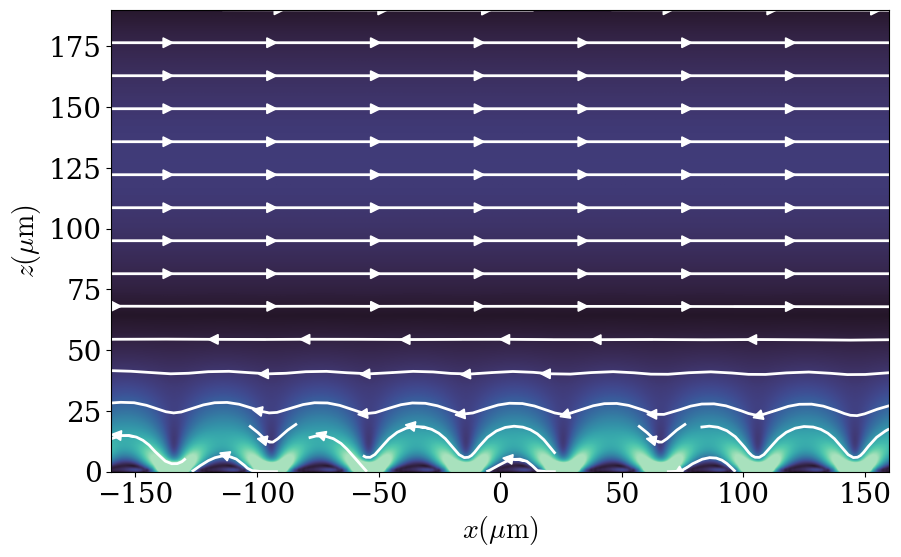

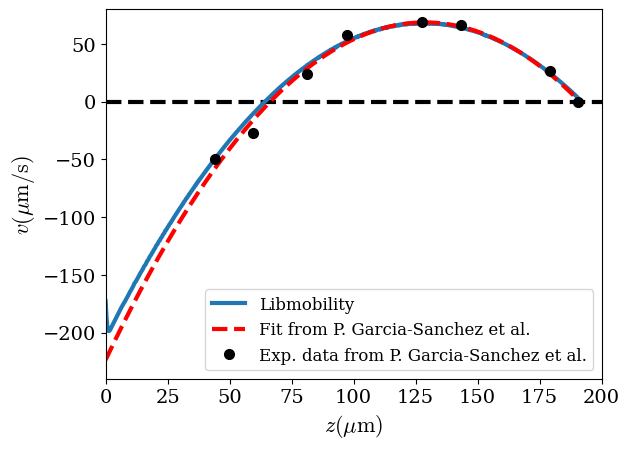

In [15]:
grid_pos = cp.load('grid_pos.npy')
grid_vel = cp.load('grid_vel.npy')
sp, vp = plotter(grid_pos=grid_pos, grid_vel=grid_vel,colorbar=False)
vp.savefig("velocityProfile.svg", format='svg') # Uncomment to save the figure
sp.savefig("transientStreamplot.svg", format='svg') # Uncomment to save the figure

In [ ]:
#Number of copies of the system in the x direction. [Number of electrodes = 4*n_repeats]
n_repeats = 20

Lx_min_trac = (n_repeats-4)*Lx0/2
Lx_max_trac = n_repeats*Lx0/2
Nx_trac = 1000
Lz_min_trac = 0
Lz_max_trac = Lz0
grid_pos, grid_vel = libmobility_electroosmotic_flow(
        v_slip=v_slip,
        hydrodynamicRadius=hydrodynamicRadius,
        n_repeats=n_repeats,
        Lx0=Lx0,
        Lz0=Lz0,
        kernel=kernel,
        Lx_min_trac=Lx_min_trac,
        Lx_max_trac=Lx_max_trac,
        Lz_min_trac=Lz_min_trac,
        Lz_max_trac=Lz_max_trac,
        Nx_trac=Nx_trac
        )
sp, vp = plotter(grid_pos=grid_pos, grid_vel=grid_vel)
plt.clf()

np.save('grid_pos_wall.npy', grid_pos)
np.save('grid_vel_wall.npy', grid_vel)

sp.savefig("transientStreamplotWall.svg", format='svg') # Uncomment to save the figure

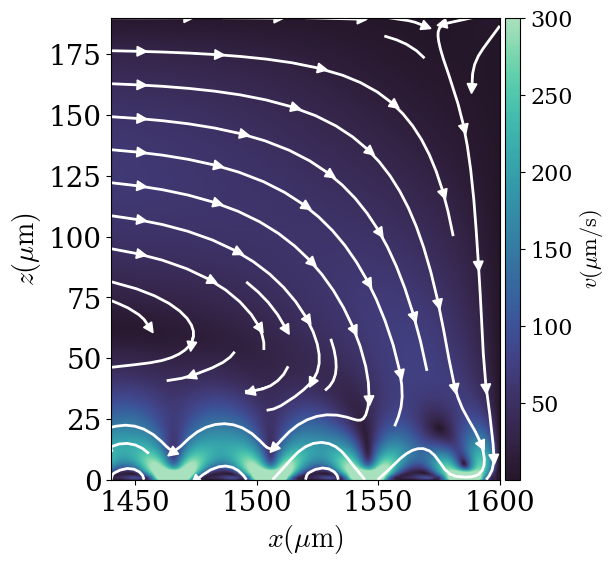

<Figure size 640x480 with 0 Axes>

In [14]:
grid_pos = cp.load('grid_pos_wall.npy')
grid_vel = cp.load('grid_vel_wall.npy')
sp, vp = plotter(grid_pos=grid_pos[500:,:,:,:], grid_vel=grid_vel[500:,:,:,:],colorbar=True)
plt.clf()
sp.savefig("transientStreamplotWall.svg", format='svg') # Uncomment to save the figure